In [71]:
import librosa
import soundfile as sf
import os
import math
import numpy as np
import glob
import matplotlib.pyplot as plt

In [72]:
input_folder = r"/home/pom/code/Pom-Savitree/maestro-v3.0.0-mp3/maestro-v3.0.0-mp3/2018"
output_dir = r"/home/pom/code/Pom-Savitree/maestro-v3.0.0-mp3/Output"

In [73]:
class AudioPreprocessingPipeline:
    # NOTE: Should we add streaming input/output? Currently we only input files and output to directories.
    def __init__(self,
                 slice_duration: int = 20,
                 n_mels: int = 128,
                 n_fft: int = 2048,
                 hop_length: int = 512):
        self.slice_duration = slice_duration
        self.n_mels = n_mels
        self.n_fft = n_fft
        self.hop_length = hop_length



    def split_audio(
        self,
        file_path: str
        ) -> np.ndarray:
        '''
        Takes in a file_path.
        Returns a numpy array containing the mel spectrograms of the splitted audio.
        '''
        total_duration = librosa.get_duration(path=file_path)
        total_slices = math.floor(total_duration / self.slice_duration)

        # n * sr / hopl
        file_sr = librosa.get_samplerate(file_path)
        n_frames = (self.slice_duration * file_sr) // self.hop_length + 1
        all_mel_specs = np.zeros(shape=(self.n_mels, int(n_frames), total_slices))

        for i in range(total_slices):
            # The current slice should start here
            start_time = i * self.slice_duration
            remaining_time = total_duration - start_time
            current_duration = min(remaining_time, self.slice_duration)

            # Skipping slicing if less than 2 sec
            # if current_duration < 2:
                # continue

            # Get the audio time series (y) and the sampling rate (sr) of the current audio slice
            y, _ = librosa.load(file_path, sr=file_sr, offset=start_time, duration=current_duration)
            mel_spec = librosa.feature.melspectrogram(y=y, sr=file_sr, n_mels=self.n_mels, n_fft=self.n_fft, hop_length=self.hop_length)

            # Convert amplitude to log scale (decibels / dB)
            mel_spec_db = librosa.power_to_db(mel_spec, ref=np.max)

            all_mel_specs[:, :, i] = mel_spec_db

        return all_mel_specs


    def save_array(
        self,
        mel_spec_mat: np.ndarray,
        file_name: str,
        output_dir: str = os.getcwd() + '/preproc_output',
        ) -> None:
        '''
        Saving Mel-Spectrogram Matrix as a NumPy binary file (.npy) from one song.
        '''
        # Create a specific output directory
        if not os.path.exists(output_dir):
            os.makedirs(output_dir, exist_ok=True)

        file_basename = os.path.splitext(os.path.basename(file_name))[0]
        npy_path = os.path.join(self.output_dir, f"{file_basename}.npy")
        np.save(npy_path, mel_spec_mat)


    def save_mel_spec_images(
        self,
        mel_spec_mat: np.ndarray,
        file_name: str,
        output_dir: str = os.getcwd() + '/mel_spec_images',
        ) -> None:
        '''
        Save all Mel-Spectrogram images into a single output directory.
        '''
        # Create a specific output directory
        if not os.path.exists(output_dir):
            os.makedirs(output_dir, exist_ok=True)

        for idx in range(mel_spec_mat.shape[-1]):
            # Getting filename
            file_basename = os.path.splitext(os.path.basename(file_name))[0]
            base_filename = f"{file_basename}_Split_Part_{idx+1}"
            plt.imsave(output_dir + '/' + base_filename + '.png', mel_spec_mat[:, :, idx])


    def run_from_folder(
        self,
        input_folder: str,
        ):
        # numpy array for each of the files in the folder.
        '''
        Takes an input folder and loops over all songs in that folder.
        Creates a 3D numpy array containing all Mel-Spectrograms for each song.

        Yields a tuple of (file_path, mel_spec_array) for each .mp3 file in the folder.
        '''
        # Searching for mp3 files
        mp3_files = glob.glob(os.path.join(input_folder, "*.mp3"))

        for index, current_file in enumerate(mp3_files):
            print(f"[{index+1}/{len(mp3_files)}] Processing: {os.path.basename(current_file)}")
            yield current_file, self.split_audio(current_file)


In [74]:
pipeline = AudioPreprocessingPipeline(
    slice_duration=20,
    n_mels=128,
    hop_length=512
)

In [75]:
all_mel_specs = pipeline.split_audio('data/mp3s/recital1-3.mp3')
all_mel_specs

array([[[-30.98641968, -18.85022736, -27.5036087 , ..., -35.52899933,
         -20.98556519, -15.37842464],
        [-25.86738205, -16.42490387, -25.5260582 , ..., -35.45708466,
         -18.29668808, -16.04863548],
        [-23.94438171, -15.36755848, -22.19368744, ..., -51.24242401,
         -22.45571709, -19.75613976],
        ...,
        [-18.18712044, -17.03633881, -24.3123436 , ..., -39.80606461,
         -30.86726761,  -7.52096844],
        [-16.30326843, -17.06114769, -22.93208694, ..., -42.28178406,
         -25.3470211 ,  -7.4989748 ],
        [-17.15608788, -23.20330048, -24.67053986, ..., -41.89959717,
         -24.40379143,  -8.81049442]],

       [[-36.02758026, -24.85195923, -33.25196838, ..., -37.74012375,
         -29.77296257, -19.70272636],
        [-37.65088272, -28.29354477, -34.85569   , ..., -38.57395935,
         -29.01119423, -22.8095665 ],
        [-31.77804184, -26.07023621, -32.03141403, ..., -47.75543213,
         -31.96409607, -21.53040314],
        ...,


In [76]:
pipeline.save_mel_spec_images(all_mel_specs, 'recital', './data/output_mel_img')

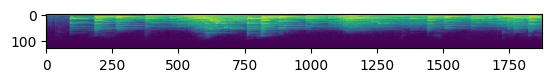

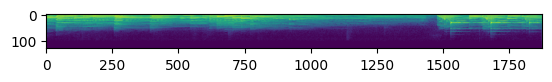

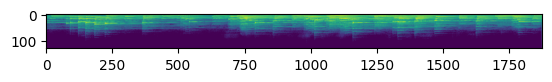

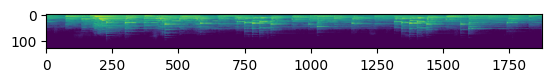

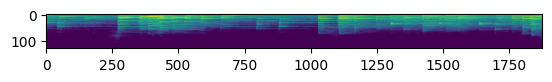

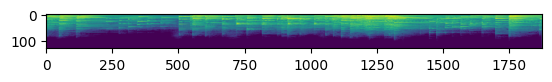

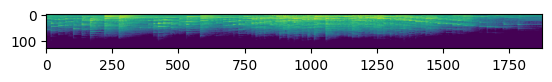

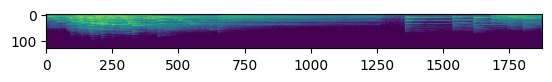

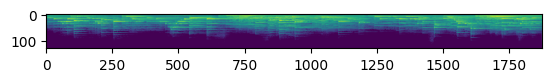

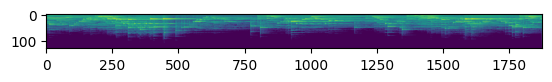

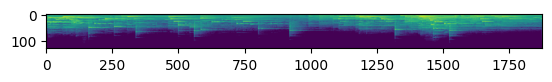

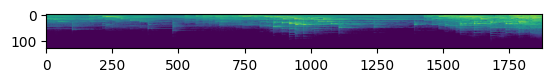

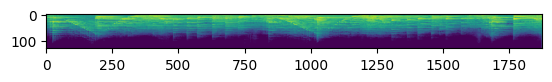

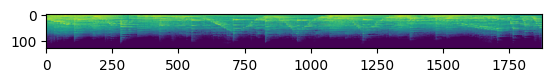

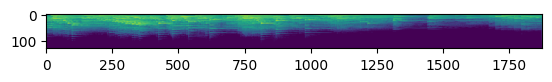

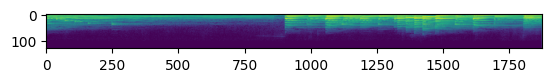

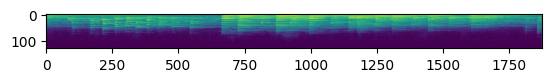

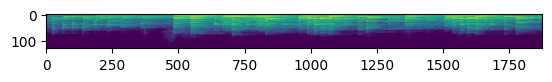

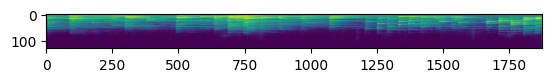

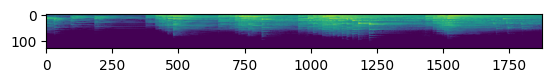

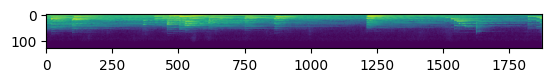

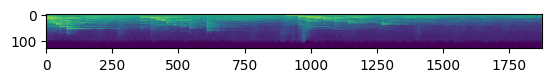

In [77]:
for idx in range(all_mel_specs.shape[-1]):
    plt.imshow(all_mel_specs[:,:, idx])
    plt.show()


In [78]:
for file_path, mel_spec in pipeline.run_from_folder('data/mp3s'):
    print(file_path, mel_spec.shape)

[1/2] Processing: midi.mp3
data/mp3s/midi.mp3 (128, 1723, 1)
[2/2] Processing: recital1-3.mp3
data/mp3s/recital1-3.mp3 (128, 1876, 22)


## MIDI Splits

In [79]:
import pretty_midi

In [80]:
midi = pretty_midi.PrettyMIDI('data/Recital1-3_MID--AUDIO_02_R1_2018_wav--3.midi')

segment_start = 0
segment_end = 20

output_midi = pretty_midi.PrettyMIDI()

for instrument in midi.instruments:
    new_instrument = pretty_midi.Instrument(program=instrument.program)

    for note in instrument.notes:
        if note.end > segment_start and note.start < segment_end:
            new_note = pretty_midi.Note(
                velocity=note.velocity,
                pitch=note.pitch,
                start=max(note.start, segment_start) - segment_start,
                end=min(note.end, segment_end) - segment_start
            )
            new_instrument.notes.append(new_note)
    output_midi.instruments.append(new_instrument)
output_midi.write("segment.mid")

## Target

In [81]:
""" MAESTRO Audio-to-Sheet-Music Pipeline
======================================
Components:
  1. MAESTRODataLoader  - loads and pairs audio + MIDI from MAESTRO dataset
  2. CQTPreprocessor    - computes Constant-Q Transform features
  3. Augmentor          - applies musical-aware augmentations
  4. build_tf_dataset() - wires everything into a tf.data.Dataset

Requirements:
  pip install tensorflow librosa pretty_midi numpy pandas
"""

import os
import json
import numpy as np
import pandas as pd
import librosa
import pretty_midi
import tensorflow as tf
from pathlib import Path
from typing import Optional, Tuple, List


In [82]:
# CONSTANTS
# ─────────────────────────────────────────────

SAMPLE_RATE = 16_000          # Hz — MT3 standard
CLIP_DURATION = 10.0          # seconds per training chunk
HOP_LENGTH = 512              # CQT hop in samples → ~32ms at 16kHz
N_BINS = 84                   # 7 octaves × 12 semitones (full piano range)
BINS_PER_OCTAVE = 12
FMIN = librosa.note_to_hz("A0")  # 27.5 Hz — lowest piano key
PIANO_ROLL_FS = 100           # piano roll frames per second
PIANO_MIN_PITCH = 21          # MIDI A0
PIANO_MAX_PITCH = 108         # MIDI C8
N_PIANO_KEYS = PIANO_MAX_PITCH - PIANO_MIN_PITCH + 1  # 88


In [83]:
# 1. DATA LOADER
# ─────────────────────────────────────────────

class MAESTRODataLoader:
    """
    Loads paired (audio, MIDI) clips from the MAESTRO v3 dataset.

    MAESTRO folder structure expected:
        maestro-v3.0.0/
            maestro-v3.0.0.json   ← metadata
            2004/
                *.wav
                *.midi
            2006/  ...

    Usage:
        loader = MAESTRODataLoader("path/to/maestro-v3.0.0")
        train_pairs = loader.get_pairs(split="train")
        audio, piano_roll = loader.load_pair(train_pairs[0])
    """

    def __init__(
        self,
        maestro_root: str,
        year: int = 2018,
        sr: int = SAMPLE_RATE,
        clip_duration: float = CLIP_DURATION,
        piano_roll_fs: int = PIANO_ROLL_FS,
    ):
        self.root = Path(maestro_root)
        self.year = year
        self.sr = sr
        self.clip_duration = clip_duration
        self.clip_samples = int(sr * clip_duration)
        self.piano_roll_fs = piano_roll_fs

        # Load metadata JSON
        meta_path = self.root / "maestro-v3.0.0.json"
        if not meta_path.exists():
            raise FileNotFoundError(f"Metadata not found at {meta_path}")
        with open(meta_path) as f:
            meta = json.load(f)
        self.metadata = pd.DataFrame(meta)

    def get_pairs(self, split: str = "train") -> List[dict]:
        """
        Returns list of {audio_path, midi_path, duration} dicts for a split.
        split: 'train' | 'validation' | 'test'
        """
        subset = self.metadata[self.metadata["split"] == split]
        subset = subset[self.metadata['year'] == self.year]
        pairs = []
        for _, row in subset.iterrows():
            bb_audio_root = Path('data/mp3s')
            bb_midi_root =  Path('data/midis')

            audio_no_wav = row['audio_filename'].replace('.wav', '.mp3')
            pairs.append({
                "audio_path": str(bb_audio_root / audio_no_wav),
                "midi_path":  str(bb_midi_root / row["midi_filename"]),
                "duration":   row["duration"],
            })
        pairs = pairs[:2]
        print(f"[MAESTRODataLoader] {split}: {len(pairs)} files found.")
        return pairs

    def load_pair(
        self,
        pair: dict,
        start_sec: Optional[float] = None,
    ) -> Tuple[np.ndarray, np.ndarray]:
        """
        Load one (audio_clip, piano_roll) pair.

        Args:
            pair: dict from get_pairs()
            start_sec: clip start time in seconds. If None, picks randomly.

        Returns:
            audio     : float32 array of shape (clip_samples,)
            piano_roll: float32 array of shape (N_PIANO_KEYS, piano_roll_frames)
                        values in [0, 1] — 1 means key is active
        """
        duration = pair["duration"]
        max_start = max(0.0, duration - self.clip_duration)

        if start_sec is None:
            start_sec = np.random.uniform(0, max_start)

        # ── Audio ──────────────────────────────────────
        audio, _ = librosa.load(
            pair["audio_path"],
            sr=self.sr,
            mono=True,
            offset=start_sec,
            duration=self.clip_duration,
        )
        audio = _pad_or_trim(audio, self.clip_samples)

        # ── Piano roll from MIDI ───────────────────────
        midi = pretty_midi.PrettyMIDI(pair["midi_path"])
        roll = midi.get_piano_roll(fs=self.piano_roll_fs)  # shape: (128, T)

        # Trim to clip window
        frame_start = int(start_sec * self.piano_roll_fs)
        frame_end = frame_start + int(self.clip_duration * self.piano_roll_fs)
        roll = roll[:, frame_start:frame_end]

        # Keep only piano range A0–C8, binarize (note on/off)
        roll = roll[PIANO_MIN_PITCH:PIANO_MAX_PITCH + 1, :]  # (88, T)
        roll = (roll > 0).astype(np.float32)

        # Pad time axis if needed
        target_frames = int(self.clip_duration * self.piano_roll_fs)
        roll = _pad_or_trim_2d(roll, target_frames, axis=1)

        return audio.astype(np.float32), roll


In [84]:
# 2. CQT PREPROCESSOR
# ─────────────────────────────────────────────

class CQTPreprocessor:
    """
    Converts raw audio waveform → log-CQT spectrogram.

    Why CQT over mel-spectrogram?
      - Frequency bins align with semitones (logarithmic pitch scale)
      - Piano A0–C8 maps cleanly to 84 bins across 7 octaves
      - Better pitch resolution in low frequencies

    Output shape: (N_BINS, time_frames, 1)  ← channel-last for TF Conv2D
    """

    def __init__(
        self,
        sr: int = SAMPLE_RATE,
        hop_length: int = HOP_LENGTH,
        n_bins: int = N_BINS,
        bins_per_octave: int = BINS_PER_OCTAVE,
        fmin: float = FMIN,
    ):
        self.sr = sr
        self.hop_length = hop_length
        self.n_bins = n_bins
        self.bins_per_octave = bins_per_octave
        self.fmin = fmin

    def compute(self, audio: np.ndarray) -> np.ndarray:
        """
        Args:
            audio: float32 waveform, shape (clip_samples,)

        Returns:
            cqt_db: float32 array, shape (N_BINS, time_frames, 1)
                    normalized to [0, 1]
        """
        cqt = librosa.cqt(
            audio,
            sr=self.sr,
            hop_length=self.hop_length,
            fmin=self.fmin,
            n_bins=self.n_bins,
            bins_per_octave=self.bins_per_octave,
        )
        # Convert to dB scale
        cqt_db = librosa.amplitude_to_db(np.abs(cqt), ref=np.max)

        # Normalize to [0, 1]
        cqt_min, cqt_max = cqt_db.min(), cqt_db.max()
        if cqt_max > cqt_min:
            cqt_db = (cqt_db - cqt_min) / (cqt_max - cqt_min)
        else:
            cqt_db = np.zeros_like(cqt_db)

        # Add channel dim for Conv2D compatibility → (bins, frames, 1)
        return cqt_db[:, :, np.newaxis].astype(np.float32)

    def tf_compute(self, audio: tf.Tensor) -> tf.Tensor:
        """TensorFlow-compatible wrapper using tf.numpy_function."""
        cqt = tf.numpy_function(
            func=self.compute,
            inp=[audio],
            Tout=tf.float32,
        )
        # Set static shape so downstream layers know what to expect
        n_frames = int(CLIP_DURATION * SAMPLE_RATE / HOP_LENGTH) + 1
        cqt.set_shape([N_BINS, n_frames, 1])
        return cqt


In [85]:
# 3. AUGMENTOR
# ─────────────────────────────────────────────

class Augmentor:
    """
    Musical-aware audio augmentations.

    Rules:
      - Time stretch / pitch shift must stay within musical range
        so piano roll labels remain valid
      - Noise and gain don't affect pitch → always safe
      - Pitch shift adjusts the target piano roll accordingly

    Usage:
        aug = Augmentor(pitch_shift_range=2, time_stretch_range=0.1)
        audio_aug, roll_aug = aug(audio, piano_roll)
    """

    def __init__(
        self,
        sr: int = SAMPLE_RATE,
        pitch_shift_range: int = 2,       # ± semitones
        time_stretch_range: float = 0.1,  # ± fraction (0.1 = ±10%)
        noise_std: float = 0.005,
        gain_range: float = 0.2,
        p_pitch_shift: float = 0.5,
        p_time_stretch: float = 0.5,
        p_noise: float = 0.3,
        p_gain: float = 0.5,
    ):
        self.sr = sr
        self.pitch_shift_range = pitch_shift_range
        self.time_stretch_range = time_stretch_range
        self.noise_std = noise_std
        self.gain_range = gain_range
        self.p_pitch_shift = p_pitch_shift
        self.p_time_stretch = p_time_stretch
        self.p_noise = p_noise
        self.p_gain = p_gain

    def __call__(
        self,
        audio: np.ndarray,
        piano_roll: np.ndarray,
    ) -> Tuple[np.ndarray, np.ndarray]:
        """
        Apply random augmentations.

        Args:
            audio     : float32, shape (clip_samples,)
            piano_roll: float32, shape (88, piano_roll_frames)

        Returns:
            Augmented (audio, piano_roll) with same shapes.
        """
        audio = audio.copy()
        piano_roll = piano_roll.copy()

        # 1. Pitch shift ──────────────────────────────
        if np.random.rand() < self.p_pitch_shift:
            n_steps = np.random.randint(-self.pitch_shift_range, self.pitch_shift_range + 1)
            if n_steps != 0:
                audio = librosa.effects.pitch_shift(audio, sr=self.sr, n_steps=n_steps)
                piano_roll = self._shift_piano_roll(piano_roll, n_steps)

        # 2. Time stretch ─────────────────────────────
        if np.random.rand() < self.p_time_stretch:
            rate = np.random.uniform(
                1 - self.time_stretch_range,
                1 + self.time_stretch_range,
            )
            audio = librosa.effects.time_stretch(audio, rate=rate)
            # Re-trim/pad to original length
            audio = _pad_or_trim(audio, int(CLIP_DURATION * self.sr))
            # Stretch piano roll inversely
            piano_roll = self._stretch_piano_roll(piano_roll, rate)

        # 3. Gaussian noise ───────────────────────────
        if np.random.rand() < self.p_noise:
            noise = np.random.normal(0, self.noise_std, audio.shape).astype(np.float32)
            audio = audio + noise

        # 4. Random gain ──────────────────────────────
        if np.random.rand() < self.p_gain:
            gain = np.random.uniform(1 - self.gain_range, 1 + self.gain_range)
            audio = audio * gain

        audio = np.clip(audio, -1.0, 1.0).astype(np.float32)
        return audio, piano_roll

    def _shift_piano_roll(self, roll: np.ndarray, n_steps: int) -> np.ndarray:
        """Shift piano roll pitch rows by n_steps semitones."""
        shifted = np.zeros_like(roll)
        if n_steps > 0:
            shifted[n_steps:, :] = roll[:-n_steps, :]
        elif n_steps < 0:
            shifted[:n_steps, :] = roll[-n_steps:, :]
        else:
            shifted = roll
        return shifted

    def _stretch_piano_roll(self, roll: np.ndarray, rate: float) -> np.ndarray:
        """Re-sample piano roll time axis to match time-stretched audio."""
        n_keys, original_frames = roll.shape
        target_frames = int(original_frames / rate)
        # Use nearest-neighbor interpolation to avoid fractional note values
        indices = np.round(np.linspace(0, original_frames - 1, target_frames)).astype(int)
        indices = np.clip(indices, 0, original_frames - 1)
        stretched = roll[:, indices]
        return _pad_or_trim_2d(stretched, original_frames, axis=1)


In [86]:
# 4. TF DATASET BUILDER
# ─────────────────────────────────────────────

def build_tf_dataset(
    maestro_root: str,
    split: str = "train",
    batch_size: int = 16,
    augment: bool = False,
    shuffle_buffer: int = 200,
    prefetch: int = tf.data.AUTOTUNE,
) -> tf.data.Dataset:
    """
    Full pipeline: MAESTRO files → batched tf.data.Dataset of (CQT, piano_roll).

    Args:
        maestro_root  : path to maestro-v3.0.0/ directory
        split         : 'train' | 'validation' | 'test'
        batch_size    : number of clips per batch
        augment       : apply augmentations (train only recommended)
        shuffle_buffer: number of samples to shuffle

    Returns:
        tf.data.Dataset yielding:
            cqt        : float32 tensor (batch, N_BINS, time_frames, 1)
            piano_roll : float32 tensor (batch, 88, piano_roll_frames)
    """
    loader = MAESTRODataLoader(maestro_root)
    preprocessor = CQTPreprocessor()
    augmentor = Augmentor() if augment else None

    pairs = loader.get_pairs(split)

    def generator():
        for pair in pairs:
            try:
                audio, roll = loader.load_pair(pair)
                if augmentor:
                    audio, roll = augmentor(audio, roll)
                cqt = preprocessor.compute(audio)
                yield cqt, roll
            except Exception as e:
                print(f"[Warning] Skipping {pair['audio_path']}: {e}")
                continue

    # Infer output shapes
    n_frames = int(CLIP_DURATION * SAMPLE_RATE / HOP_LENGTH) + 1
    roll_frames = int(CLIP_DURATION * PIANO_ROLL_FS)

    dataset = tf.data.Dataset.from_generator(
        generator,
        output_signature=(
            tf.TensorSpec(shape=(N_BINS, n_frames, 1), dtype=tf.float32),
            tf.TensorSpec(shape=(N_PIANO_KEYS, roll_frames), dtype=tf.float32),
        ),
    )

    if split == "train":
        dataset = dataset.shuffle(shuffle_buffer)

    dataset = (
        dataset
        .batch(batch_size, drop_remainder=True)
        .prefetch(prefetch)
    )

    return dataset


In [87]:
# HELPERS
# ─────────────────────────────────────────────

def _pad_or_trim(audio: np.ndarray, length: int) -> np.ndarray:
    if len(audio) >= length:
        return audio[:length]
    return np.pad(audio, (0, length - len(audio)))


def _pad_or_trim_2d(arr: np.ndarray, length: int, axis: int = 1) -> np.ndarray:
    current = arr.shape[axis]
    if current >= length:
        return np.take(arr, range(length), axis=axis)
    pad_width = [(0, 0)] * arr.ndim
    pad_width[axis] = (0, length - current)
    return np.pad(arr, pad_width)


In [88]:
# from maestro_pipeline_CQT import MAESTRODataLoader, CQTPreprocessor

loader = MAESTRODataLoader("./data", clip_duration=CLIP_DURATION)
preprocessor = CQTPreprocessor()

# Point to any single mp3 + midi pair
pair = {
    'audio_path': './data/mp3s/midi.mp3',
    'midi_path':  './data/midis/midi.mid',
    'duration': 26
    }

audio, piano_roll = loader.load_pair(pair, start_sec=13)
cqt = preprocessor.compute(audio)

print(f"CQT shape:        {cqt.shape}")
print(f"Piano roll shape: {piano_roll.shape}")

CQT shape:        (84, 313, 1)
Piano roll shape: (88, 1000)


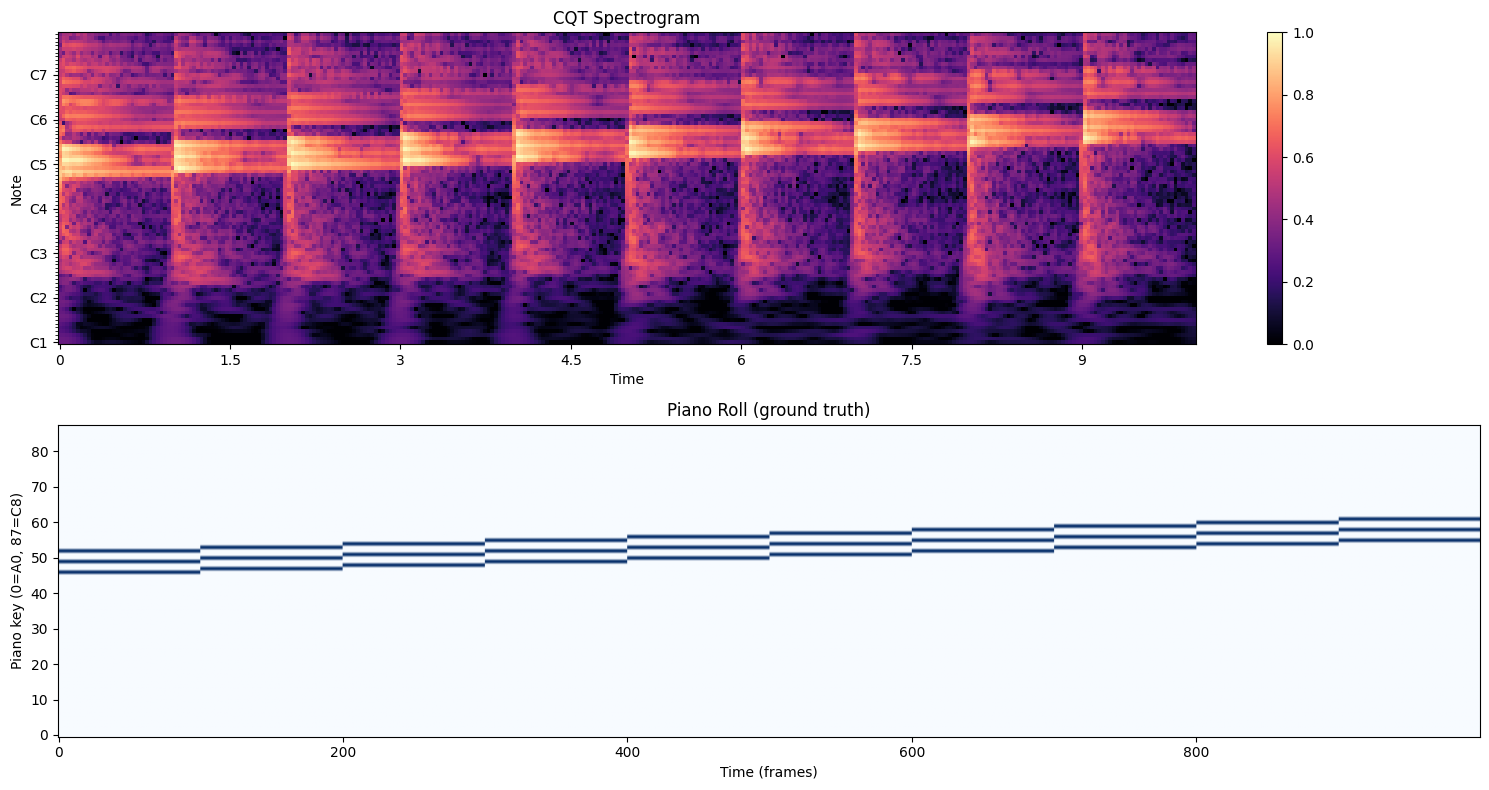

In [89]:
fig, axes = plt.subplots(2, 1, figsize=(15, 8))

axes[0].set_title("CQT Spectrogram")
librosa.display.specshow(cqt[:, :, 0], sr=16000, hop_length=512, x_axis="time", y_axis="cqt_note", ax=axes[0])
plt.colorbar(axes[0].collections[0], ax=axes[0])

axes[1].set_title("Piano Roll (ground truth)")
axes[1].imshow(piano_roll, aspect="auto", origin="lower", cmap="Blues")
axes[1].set_xlabel("Time (frames)")
axes[1].set_ylabel("Piano key (0=A0, 87=C8)")

plt.tight_layout()
plt.show()

## Model

In [ ]:
def OLD_build_model(n_bins=84, n_frames=313, n_keys=88, n_time=1000):
    inputs = tf.keras.Input(shape=(n_bins, n_frames, 1))

    # CNN Block
    x = tf.keras.layers.Conv2D(64, (3,3), activation='relu', padding='same')(inputs)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Conv2D(128, (3,3), activation='relu', padding='same')(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.MaxPooling2D((2,2))(x)
    x = tf.keras.layers.Dropout(0.3)(x)

    x = tf.keras.layers.Conv2D(256, (3,3), activation='relu', padding='same')(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.MaxPooling2D((2,2))(x)
    x = tf.keras.layers.Dropout(0.3)(x)





    # Reshape for Transformer: Shape (None, 1638, 256)
    x = tf.keras.layers.Reshape((-1, x.shape[-1]))(x)

    # Add a simple trainable positional embedding
    seq_len = x.shape[1]
    channels = x.shape[2]
    position_embedding = tf.keras.layers.Embedding(input_dim=seq_len, output_dim=channels)(tf.range(start=0, limit=seq_len, delta=1))
    x = x + position_embedding # Now the Transformer knows the order of events!




    # Transformer Block
    x = tf.keras.layers.MultiHeadAttention(num_heads=8, key_dim=64)(x, x)
    x = tf.keras.layers.LayerNormalization()(x)




    # 1. Your tensor coming out of the attention block
    # Shape: (None, 1638, 256)

    # 2. Trick Keras by adding a dummy image width dimension of 1
    # New Shape: (None, 1638, 1, 256) -> (Batch, Height, Width, Channels)
    x = tf.keras.layers.Reshape((1638, 1, 256))(x)

    # 3. Resize only the "Height" (the timeline) from 1638 to 1000
    # New Shape: (None, 1000, 1, 256)
    x = tf.keras.layers.Resizing(1000, 1, interpolation='bilinear')(x)

    # 4. Remove the dummy width dimension to return to a 3D sequence
    # New Shape: (None, 1000, 256)
    x = tf.keras.layers.Reshape((1000, 256))(x)

    # 5. Project the 256 feature channels to your 88 piano keys
    # New Shape: (None, 1000, 88)
    x = tf.keras.layers.Dense(n_keys, activation='sigmoid')(x)

    # 6. Swap dimensions to match your required target format: (88, 1000)
    # Final Shape: (None, 88, 1000)
    outputs = tf.keras.layers.Permute((2, 1))(x)


    model = tf.keras.Model(inputs, outputs)
    return model

model = build_model()
model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_5       │ (None, 84, 313,   │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_15 (Conv2D)  │ (None, 84, 313,   │        640 │ input_layer_5[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 84, 313,   │        256 │ conv2d_15[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_16 (Conv2D)  │ (None, 84, 313,   │     73,856 │ batch_normalizat… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 84, 313,   │        512 │ conv2d_16[0][0]   │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_10    │ (None, 42, 156,   │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_15          │ (None, 42, 156,   │          0 │ max_pooling2d_10… │
│ (Dropout)           │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_17 (Conv2D)  │ (None, 42, 156,   │    295,168 │ dropout_15[0][0]  │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 42, 156,   │      1,024 │ conv2d_17[0][0]   │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_11    │ (None, 21, 78,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_16          │ (None, 21, 78,    │          0 │ max_pooling2d_11… │
│ (Dropout)           │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_6 (Reshape) │ (None, 1638, 256) │          0 │ dropout_16[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_5 (Add)         │ (None, 1638, 256) │          0 │ reshape_6[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 1638, 256) │    526,080 │ add_5[0][0],      │
│ (MultiHeadAttentio… │                   │            │ add_5[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 1638, 256) │        512 │ multi_head_atten… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_7 (Reshape) │ (None, 1638, 1,   │          0 │ layer_normalizat… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resizing_2          │ (None, 1000, 1,   │          0 │ reshape_7[0][0]   │
│ (Resizing)          │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 920,664 (3.51 MB)

 Trainable params: 919,768 (3.51 MB)

 Non-trainable params: 896 (3.50 KB)

In [91]:
import tensorflow as tf

def build_model(n_bins=N_BINS, n_frames=313, n_keys=N_PIANO_KEYS, n_time=int(CLIP_DURATION * PIANO_ROLL_FS)):
    inputs = tf.keras.Input(shape=(n_bins, n_frames, 1))

    # --- CNN Block ---
    x = tf.keras.layers.Conv2D(64, (3,3), activation='relu', padding='same')(inputs)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Conv2D(128, (3,3), activation='relu', padding='same')(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.MaxPooling2D((2,2))(x)  # Downsampling spatial dimensions
    x = tf.keras.layers.Dropout(0.3)(x)

    x = tf.keras.layers.Conv2D(256, (3,3), activation='relu', padding='same')(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.MaxPooling2D((2,2))(x)  # Tensor output shape here is (None, 21, 78, 256)
    x = tf.keras.layers.Dropout(0.3)(x)

    # --- FIX: Natively collapse PITCH using Keras Layers ---
    # Global Average Pooling flattens spatial arrays, but setting keepdims=True
    # preserves the layout as (None, 1, 1, 256) which isn't what we want.
    # Instead, we use a standard Reshape to swap axis context, or average out Pitch.

    # We squash ONLY the Pitch axis (21 bins) down to 1 while leaving Time (78) alone.
    # To do this natively, we use Keras' functional operations API (tf.keras.ops if Keras 3)
    # or a robust Lambda wrapper that plays perfectly with the standard compiler graph.
    x = tf.keras.layers.Lambda(lambda t: tf.reduce_mean(t, axis=1))(x) # Shape becomes: (None, 78, 256)

    # --- Add Positional Tracking for the Transformer ---
    # Ensures the attention block knows the exact order of your 78 chronological slices.
    seq_len = 78
    pos_indices = tf.range(start=0, limit=seq_len, delta=1)
    pos_embed = tf.keras.layers.Embedding(input_dim=seq_len, output_dim=256)(pos_indices)
    x = x + pos_embed  # Pure (None, 78, 256) sequential data

    # --- Transformer Block ---
    x = tf.keras.layers.MultiHeadAttention(num_heads=8, key_dim=64)(x, x)
    x = tf.keras.layers.LayerNormalization()(x)

    # --- Learn the Time Mapping (No Blur) ---
    # Dynamically maps 78 audio steps up to 1000 piano-roll time targets.
    x = tf.keras.layers.Permute((2, 1))(x)       # Shape: (None, 256, 78)
    x = tf.keras.layers.Dense(n_time)(x)         # Shape: (None, 256, 1000)
    x = tf.keras.layers.Permute((2, 1))(x)       # Shape: (None, 1000, 256)

    # --- Output Block ---
    # Map 256 features directly to your 88 individual keys across every step.
    x = tf.keras.layers.Dense(n_keys)(x)         # Shape: (None, 1000, 88)

    # Rearrange dimensions to deliver your target formatting: (None, 88, 1000)
    outputs = tf.keras.layers.Permute((2, 1))(x)
    outputs = tf.keras.layers.Activation('sigmoid')(outputs)

    model = tf.keras.Model(inputs, outputs)
    return model

model = build_model()
model.summary()


Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_6       │ (None, 84, 313,   │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_18 (Conv2D)  │ (None, 84, 313,   │        640 │ input_layer_6[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 84, 313,   │        256 │ conv2d_18[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_19 (Conv2D)  │ (None, 84, 313,   │     73,856 │ batch_normalizat… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 84, 313,   │        512 │ conv2d_19[0][0]   │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_12    │ (None, 42, 156,   │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_18          │ (None, 42, 156,   │          0 │ max_pooling2d_12… │
│ (Dropout)           │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_20 (Conv2D)  │ (None, 42, 156,   │    295,168 │ dropout_18[0][0]  │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 42, 156,   │      1,024 │ conv2d_20[0][0]   │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_13    │ (None, 21, 78,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_19          │ (None, 21, 78,    │          0 │ max_pooling2d_13… │
│ (Dropout)           │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_3 (Lambda)   │ (None, 78, 256)   │          0 │ dropout_19[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_6 (Add)         │ (None, 78, 256)   │          0 │ lambda_3[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 78, 256)   │    526,080 │ add_6[0][0],      │
│ (MultiHeadAttentio… │                   │            │ add_6[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 78, 256)   │        512 │ multi_head_atten… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ permute_8 (Permute) │ (None, 256, 78)   │          0 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_7 (Dense)     │ (None, 256, 1000) │     79,000 │ permute_8[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ permute_9 (Permute) │ (None, 1000, 256) │          0 │ dense_7[0][0]     │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 999,664 (3.81 MB)

 Trainable params: 998,768 (3.81 MB)

 Non-trainable params: 896 (3.50 KB)

In [92]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy'],
)

In [93]:
# If your data has 10x more zeros than ones, set pos_weight to roughly 10.0
loss_fn = tf.keras.losses.BinaryCrossentropy(
    from_logits=False,
    reduction="sum_over_batch_size"
)

# Note: In standard Keras, to inject a raw 'pos_weight', you can also wrap
# the native TensorFlow function easily:
def weighted_bce(y_true, y_pred):
    return tf.nn.weighted_cross_entropy_with_logits(
        labels=y_true,
        logits=tf.math.log(y_pred / (1.0 - y_pred + 1e-7) + 1e-7), # convert back to logits safely
        pos_weight=10.0
    )

model.compile(optimizer='adam', loss=weighted_bce, metrics=['accuracy'])


In [95]:
# Add batch dimension
cqt_input = np.expand_dims(cqt, axis=0)        # (1, 84, 313, 1)
piano_roll_input = np.expand_dims(piano_roll, axis=0)  # (1, 88, 1000)

print(cqt_input.shape)
print(piano_roll_input.shape)

history = model.fit(
    cqt_input,
    piano_roll_input,
    epochs=10,
)

(1, 84, 313, 1)
(1, 88, 1000)
Epoch 1/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 274ms/step - accuracy: 0.0000e+00 - loss: 0.8194
Epoch 2/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 162ms/step - accuracy: 0.0000e+00 - loss: 0.7836
Epoch 3/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 167ms/step - accuracy: 0.0000e+00 - loss: 0.7437
Epoch 4/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 331ms/step - accuracy: 0.0000e+00 - loss: 0.7011
Epoch 5/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 152ms/step - accuracy: 0.0000e+00 - loss: 0.6573
Epoch 6/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 170ms/step - accuracy: 0.0000e+00 - loss: 0.6134
Epoch 7/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 151ms/step - accuracy: 0.0000e+00 - loss: 0.5708
Epoch 8/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 152ms/step - accuracy: 0.0000e+00 - loss: 0.5304
Epoch 9/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 211ms/step - accuracy: 0.0000e+00 - loss: 0.4928
Epoch 10/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 169ms/step - accuracy: 0.0000e+00 - loss: 0.4581


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 192ms/step


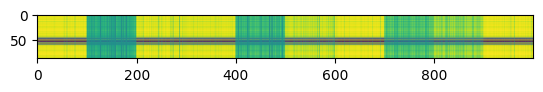

In [96]:

pred = np.reshape(model.predict(cqt_input), shape=(88, 1000))
# pred = np.reshape(model.predict(np.zeros_like(cqt_input)), shape=(88, 1000))
plt.imshow(pred)

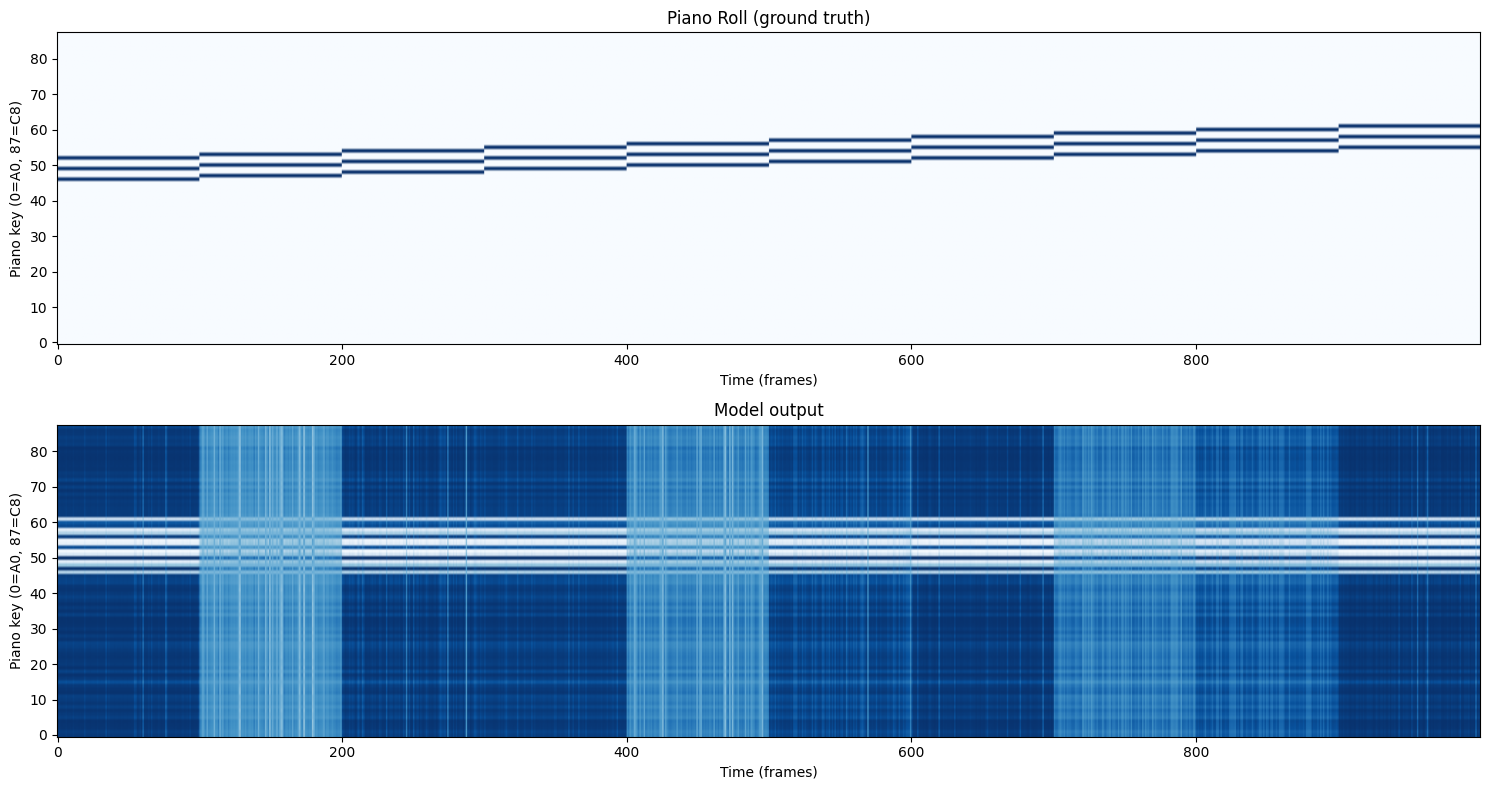

In [97]:
fig, axes = plt.subplots(2, 1, figsize=(15, 8))

axes[0].set_title("Piano Roll (ground truth)")
axes[0].imshow(piano_roll, aspect="auto", origin="lower", cmap="Blues")
axes[0].set_xlabel("Time (frames)")
axes[0].set_ylabel("Piano key (0=A0, 87=C8)")

axes[1].set_title("Model output")
axes[1].imshow(pred, aspect="auto", origin="lower", cmap="Blues")
axes[1].set_xlabel("Time (frames)")
axes[1].set_ylabel("Piano key (0=A0, 87=C8)")

plt.tight_layout()
plt.show()

In [98]:
audio_from_pianoroll(piano_roll)

NameError: name 'audio_from_pianoroll' is not defined

In [ ]:
audio_from_pianoroll(pred)

## Audio from pianoroll

In [99]:
import pandas as pd
import pretty_midi

def csv_to_midi(csv_path, output_midi_path, fs=50, threshold=0.5):
    """
    Converts an (88, T) piano roll CSV file into a standard MIDI file.

    Parameters:
    - csv_path: Path to your saved piano roll CSV file.
    - output_midi_path: The filename/path for the generated MIDI file.
    - fs: Sampling frequency (frames per second).
          e.g., fs=50 means each column represents 20 milliseconds.
    - threshold: Activation threshold for probabilities (0.0 to 1.0).
    """
    # 1. Load the CSV data (ignoring headers if they exist)
    df = pd.read_csv(csv_path, header=None)
    piano_roll_88 = df.values  # Shape: (88, Time)

    # 2. Transpose to (Time, 88) so we can iterate through time steps row-by-row
    piano_roll = piano_roll_88.T

    # 3. Initialize PrettyMIDI objects
    pm = pretty_midi.PrettyMIDI()
    instrument = pretty_midi.Instrument(program=0)  # 0 = Acoustic Grand Piano

    # Pad the matrix with an extra empty step at the end to catch any final note-offs
    padded_roll = np.pad(piano_roll, ((0, 1), (0, 0)), 'constant')
    active_notes = {}

    # 4. Parse time steps
    for step in range(padded_roll.shape[0]):
        current_time = step / fs

        for idx in range(88):
            midi_pitch = idx + 21  # Offset index by 21 (Key 0 maps to A0 / MIDI 21)
            activation_value = padded_roll[step, idx]
            is_note_active = activation_value > threshold

            # Case A: Note just turned on
            if is_note_active and midi_pitch not in active_notes:
                # Scale velocity back to full 0-127 MIDI range if it's a 0.0-1.0 probability
                velocity = int(activation_value * 127) if activation_value <= 1.0 else int(activation_value)
                velocity = max(min(velocity, 127), 1)  # Clamp between 1 and 127
                active_notes[midi_pitch] = (current_time, velocity)

            # Case B: Note just turned off
            elif not is_note_active and midi_pitch in active_notes:
                start_time, note_velocity = active_notes.pop(midi_pitch)

                # Append the completed note to our track
                note = pretty_midi.Note(
                    velocity=note_velocity,
                    pitch=midi_pitch,
                    start=start_time,
                    end=current_time
                )
                instrument.notes.append(note)

    # 5. Save the file
    pm.instruments.append(instrument)
    pm.write(output_midi_path)
    print(f"🎉 Success! MIDI file saved to: {output_midi_path}")


In [100]:
# # --- Execute the script ---
# csv_to_midi(
    # csv_path='piano_roll_output.csv',
    # output_midi_path='transcribed_song.mid',
    # fs=100,          # Adjust this if your song plays back too fast or too slow!
    # threshold=0.5   # Adjust if notes are missing or blending together too much
# )

In [101]:
def play_midi_pure_python(midi_path, sample_rate=44100):
    from IPython.display import Audio
    """

    """
    # Load MIDI file
    pm = pretty_midi.PrettyMIDI(midi_path)

    total_time = pm.get_end_time()
    total_samples = int(total_time * sample_rate)
    audio_data = np.zeros(total_samples)

    for instrument in pm.instruments:
        for note in instrument.notes:
            start_sample = int(note.start * sample_rate)
            end_sample = int(note.end * sample_rate)

            if end_sample <= start_sample:
                continue

            # Convert MIDI pitch to frequency (Hz)
            frequency = pretty_midi.note_number_to_hz(note.pitch)

            # Generate the sound wave for this note's duration
            duration = (end_sample - start_sample) / sample_rate
            t = np.linspace(0, duration, end_sample - start_sample, endpoint=False)

            # Smooth out the volume fade so notes don't aggressively "click" when ending
            fade_out = np.linspace(1.0, 0.0, len(t)) ** 0.5
            note_wave = np.sin(2 * np.pi * frequency * t) * 0.1 * fade_out

            # Mix this note into the master song audio track
            audio_data[start_sample:end_sample] += note_wave

    # Normalize audio levels to prevent clipping/distortion
    if np.max(np.abs(audio_data)) > 0:
        audio_data = audio_data / np.max(np.abs(audio_data))

    return audio_data, sample_rate


In [102]:
# # --- EXECUTE AND PLAY ---
# try:
#     print("Synthesizing transcribed_song.mid using Python...")
#     audio, sr = play_midi_pure_python('midi.mid')
#     print("🎵 Synthesis Successful! Loading interactive notebook player:")
#     display(Audio(audio, rate=sr))
# except Exception as e:
#     print(f"❌ Error playing file: {e}")

In [103]:
def audio_from_pianoroll(piano_roll):
    pr_path = './data/piano_roll.csv'
    midi_path = './data/midis/piano_roll.mid'
    np.savetxt(pr_path, piano_roll, delimiter=",")
    csv_to_midi(pr_path, midi_path, fs=50, threshold=0.5)
    audio, sr = play_midi_pure_python(midi_path)
    # print("🎵 Synthesis Successful! Loading interactive notebook player:")
    display(Audio(audio, rate=sr))


## MEL SPECTROGRAM MODEL

In [104]:
mel_model = build_model(n_bins=128, n_frames=1876, n_keys=88)
mel_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy'],
)
mel_specs = pipeline.split_audio('./data/mp3s/recital1-3.mp3')[:,:,0]

mel_input = np.expand_dims(mel_specs, axis=0)
piano_roll_input = np.expand_dims(piano_roll, axis=0)


ValueError: Cannot broadcast shape, the failure dim has value 469, which cannot be broadcasted to 78. Input shapes are: [None, 469, 256] and [78, 256].

In [ ]:

mel_history = mel_model.fit(
    mel_input,
    piano_roll_input,
    epochs=1,
)

## More model training

In [107]:
dataloader = MAESTRODataLoader('./data/')

In [108]:
train_ds = build_tf_dataset("./data", split="train", batch_size=16, augment=False)
val_ds =   build_tf_dataset("./data", split="validation", batch_size=16, augment=False)


[MAESTRODataLoader] train: 2 files found.
[MAESTRODataLoader] validation: 2 files found.


/var/folders/cx/3v60q7ys0z18j2r8p2dd7ms40000gp/T/ipykernel_88618/2482568909.py:51: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  subset = subset[self.metadata['year'] == self.year]
/var/folders/cx/3v60q7ys0z18j2r8p2dd7ms40000gp/T/ipykernel_88618/2482568909.py:51: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  subset = subset[self.metadata['year'] == self.year]


In [109]:
ds = build_tf_dataset('data/')
ds

/var/folders/cx/3v60q7ys0z18j2r8p2dd7ms40000gp/T/ipykernel_88618/2482568909.py:51: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  subset = subset[self.metadata['year'] == self.year]


[MAESTRODataLoader] train: 2 files found.


<_PrefetchDataset element_spec=(TensorSpec(shape=(16, 84, 313, 1), dtype=tf.float32, name=None), TensorSpec(shape=(16, 88, 1000), dtype=tf.float32, name=None))>

In [110]:
batch_size = 16
# 1. Calculate the steps manually
num_train_pairs = len(loader.get_pairs("train")) # or access via your dataset object if saved
steps_per_epoch = num_train_pairs // batch_size

num_val_pairs = len(loader.get_pairs("validation"))
validation_steps = num_val_pairs // batch_size


train_ds_fixed = train_ds.apply(tf.data.experimental.assert_cardinality(steps_per_epoch))
val_ds_fixed = val_ds.apply(tf.data.experimental.assert_cardinality(validation_steps))

print_callback = tf.keras.callbacks.LambdaCallback(
    on_epoch_end=lambda epoch, logs: print(
        'hello'
    )
)

# 2. Pass them to model.fit
history = model.fit(
    train_ds_fixed,
    validation_data=val_ds_fixed,
    epochs=20,
    steps_per_epoch=steps_per_epoch,   # <-- Fixes the progress bar target
    validation_steps=validation_steps, # <-- Fixes the validation progress bar
    verbose=2,
    callbacks=[print_callback],
)


[MAESTRODataLoader] train: 2 files found.
[MAESTRODataLoader] validation: 2 files found.
Epoch 1/20


/var/folders/cx/3v60q7ys0z18j2r8p2dd7ms40000gp/T/ipykernel_88618/2482568909.py:51: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  subset = subset[self.metadata['year'] == self.year]
/var/folders/cx/3v60q7ys0z18j2r8p2dd7ms40000gp/T/ipykernel_88618/2482568909.py:51: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  subset = subset[self.metadata['year'] == self.year]
/Users/bastiaanboland/.pyenv/versions/3.10.6/envs/sheetify/lib/python3.10/site-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


hello


ValueError: math domain error

In [111]:
import librosa
import os
import math
import numpy as np
import glob
import matplotlib.pyplot as plt
import pretty_midi
import tensorflow as tf
from pathlib import Path

# # #── Constants matching maestro_pipeline_CQT.py ──────────────────
# SAMPLE_RATE     = 16_000   # resampled to match CQT pipeline
# CLIP_DURATION   = 10.0     # seconds — matches model input
# HOP_LENGTH      = 512      # matches CQT pipeline
N_MELS          = 84       # changed from 128 → must match model input (84, 313, 1)
# PIANO_ROLL_FS   = 100      # frames per second — matches CQT pipeline
# PIANO_MIN_PITCH = 21       # MIDI A0
# PIANO_MAX_PITCH = 108      # MIDI C8
# N_PIANO_KEYS    = PIANO_MAX_PITCH - PIANO_MIN_PITCH + 1  # 88


class AudioPreprocessingPipeline:
    def __init__(self,
                 slice_duration: float = CLIP_DURATION,
                 n_mels: int = N_MELS,
                 n_fft: int = 2048,
                 hop_length: int = HOP_LENGTH,
                 sr: int = SAMPLE_RATE):
        self.slice_duration = slice_duration
        self.n_mels = n_mels
        self.n_fft = n_fft
        self.hop_length = hop_length
        self.sr = sr
        self.clip_samples = int(sr * slice_duration)

    def compute_mel(self, audio: np.ndarray) -> np.ndarray:
        """
        Converts raw audio waveform → normalized log-mel spectrogram.

        Args:
            audio: float32 waveform, shape (clip_samples,)

        Returns:
            mel_db: float32 array, shape (N_MELS, time_frames, 1)
                    normalized to [0, 1] — matches CQT pipeline output format
        """
        mel_spec = librosa.feature.melspectrogram(
            y=audio,
            sr=self.sr,
            n_mels=self.n_mels,
            n_fft=self.n_fft,
            hop_length=self.hop_length,
        )
        mel_db = librosa.power_to_db(mel_spec, ref=np.max)

        # Normalize to [0, 1] — same as CQT pipeline
        mel_min, mel_max = mel_db.min(), mel_db.max()
        if mel_max > mel_min:
            mel_db = (mel_db - mel_min) / (mel_max - mel_min)
        else:
            mel_db = np.zeros_like(mel_db)

        # Add channel dim → (n_mels, frames, 1)
        return mel_db[:, :, np.newaxis].astype(np.float32)

    def load_pair(
        self,
        audio_path: str,
        midi_path: str,
        start_sec: float = None,
    ):
        """
        Load one (mel_spectrogram, piano_roll) pair.
        Same interface as MAESTRODataLoader.load_pair() for easy comparison.

        Returns:
            mel  : float32 (N_MELS, time_frames, 1)
            roll : float32 (88, piano_roll_frames)
        """
        # Get duration for random start
        duration = librosa.get_duration(path=audio_path)
        max_start = max(0.0, duration - self.slice_duration)
        if start_sec is None:
            start_sec = np.random.uniform(0, max_start)

        # Load audio — resample to 16kHz mono (same as CQT pipeline)
        audio, _ = librosa.load(
            audio_path,
            sr=self.sr,
            mono=True,
            offset=start_sec,
            duration=self.slice_duration,
        )
        audio = self._pad_or_trim(audio)

        # Compute mel spectrogram
        mel = self.compute_mel(audio)

        # Load MIDI → piano roll
        midi = pretty_midi.PrettyMIDI(midi_path)
        roll = midi.get_piano_roll(fs=PIANO_ROLL_FS)
        frame_start = int(start_sec * PIANO_ROLL_FS)
        frame_end = frame_start + int(self.slice_duration * PIANO_ROLL_FS)
        roll = roll[:, frame_start:frame_end]
        roll = roll[PIANO_MIN_PITCH:PIANO_MAX_PITCH + 1, :]
        roll = (roll > 0).astype(np.float32)
        roll = self._pad_or_trim_roll(roll)

        return mel, roll

    def build_tf_dataset(
        self,
        maestro_root: str,
        split: str = "train",
        batch_size: int = 16,
        shuffle_buffer: int = 200,
        prefetch: int = tf.data.AUTOTUNE,
    ) -> tf.data.Dataset:
        """
        Same interface as build_tf_dataset() in maestro_pipeline_CQT.py.
        Produces (mel_spectrogram, piano_roll) batches instead of (CQT, piano_roll).
        """
        import json
        import pandas as pd

        meta_path = next(Path(maestro_root).glob("*.json"))
        with open(meta_path) as f:
            meta = json.load(f)
        df = pd.DataFrame(meta)
        subset = df[df["split"] == split]

        pairs = []
        for _, row in subset.iterrows():
            pairs.append({
                "audio_path": str(Path(maestro_root) / row["audio_filename"]).replace(".wav", ".mp3"),
                "midi_path":  str(Path(maestro_root) / row["midi_filename"]),
                "duration":   row["duration"],
            })

        print(f"[MelPipeline] {split}: {len(pairs)} files found.")

        pipeline = self

        def generator():
            for pair in pairs:
                try:
                    mel, roll = pipeline.load_pair(pair["audio_path"], pair["midi_path"])
                    yield mel, roll
                except Exception as e:
                    print(f"[Warning] Skipping {pair['audio_path']}: {e}")
                    continue

        n_frames = int(self.slice_duration * self.sr / self.hop_length) + 1
        roll_frames = int(self.slice_duration * PIANO_ROLL_FS)

        dataset = tf.data.Dataset.from_generator(
            generator,
            output_signature=(
                tf.TensorSpec(shape=(self.n_mels, n_frames, 1), dtype=tf.float32),
                tf.TensorSpec(shape=(N_PIANO_KEYS, roll_frames),  dtype=tf.float32),
            ),
        )

        if split == "train":
            dataset = dataset.shuffle(shuffle_buffer)

        dataset = dataset.batch(batch_size, drop_remainder=True).prefetch(prefetch)
        return dataset

    def save_mel_spec_images(
        self,
        mel_spec_mat: np.ndarray,
        file_name: str,
        output_dir: str = os.getcwd() + '/mel_spec_images',
    ) -> None:
        """Save mel spectrogram slices as PNG images."""
        os.makedirs(output_dir, exist_ok=True)
        file_basename = os.path.splitext(os.path.basename(file_name))[0]
        for idx in range(mel_spec_mat.shape[-1]):
            base_filename = f"{file_basename}_Split_Part_{idx+1}"
            plt.imsave(output_dir + '/' + base_filename + '.png', mel_spec_mat[:, :, idx])

    def run_from_folder(self, input_folder: str):
        """
        Yields (file_path, mel_spec_array) for each .mp3 in folder.
        Same interface as before.
        """
        mp3_files = glob.glob(os.path.join(input_folder, "*.mp3"))
        for index, current_file in enumerate(mp3_files):
            print(f"[{index+1}/{len(mp3_files)}] Processing: {os.path.basename(current_file)}")
            yield current_file, self.split_audio(current_file)

    def split_audio(self, file_path: str) -> np.ndarray:
        """Original method preserved — splits full audio into mel spectrogram slices."""
        total_duration = librosa.get_duration(path=file_path)
        total_slices = math.floor(total_duration / self.slice_duration)
        n_frames = (self.slice_duration * self.sr) // self.hop_length + 1
        all_mel_specs = np.zeros(shape=(self.n_mels, int(n_frames), total_slices))

        for i in range(total_slices):
            start_time = i * self.slice_duration
            remaining_time = total_duration - start_time
            current_duration = min(remaining_time, self.slice_duration)
            y, _ = librosa.load(file_path, sr=self.sr, offset=start_time, duration=current_duration)
            mel_spec = librosa.feature.melspectrogram(
                y=y, sr=self.sr, n_mels=self.n_mels, n_fft=self.n_fft, hop_length=self.hop_length
            )
            mel_db = librosa.power_to_db(mel_spec, ref=np.max)
            mel_min, mel_max = mel_db.min(), mel_db.max()
            if mel_max > mel_min:
                mel_db = (mel_db - mel_min) / (mel_max - mel_min)
            all_mel_specs[:, :, i] = mel_db

        return all_mel_specs

    # ── Helpers ────────────────────────────────────────────────────
    def _pad_or_trim(self, audio: np.ndarray) -> np.ndarray:
        if len(audio) >= self.clip_samples:
            return audio[:self.clip_samples]
        return np.pad(audio, (0, self.clip_samples - len(audio)))

    def _pad_or_trim_roll(self, roll: np.ndarray) -> np.ndarray:
        target = int(self.slice_duration * PIANO_ROLL_FS)
        if roll.shape[1] >= target:
            return roll[:, :target]
        return np.pad(roll, ((0, 0), (0, target - roll.shape[1])))

In [112]:
app = AudioPreprocessingPipeline()

In [114]:
pair

{'audio_path': './data/mp3s/midi.mp3',
 'midi_path': './data/midis/midi.mid',
 'duration': 26}